# The Distributions of the $df$, for simulated fluxes with different combinations of the noise-scaling factor $k$ and the multiplicative flux-bias factor $m$. 

In this toy model, both a reduction in noise amplitude and a multiplicative suppression of the measured fluxes can narrow the $df_{\mathrm{sim}}$ distribution. Flux-ratio diagnostics are therefore required to distinguish genuine noise reduction from systematic flux bias.

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from matplotlib import pyplot as plt

In [2]:
path = '../data saved/'
df = pd.read_csv(path + 'flagship.csv', comment='#')
sub = df[~np.isnan(df.pau_nb455_el)]

In [3]:
flux_nl = sub.pau_nb455_el
sigma = sub.flux_err_sigma_pau_nb455

In [4]:
def gen_sim(m, k):
    np.random.seed(42)
    flux1 = m*(flux_nl + k*sigma * np.random.randn(len(flux_nl)))
    flux2 = m*(flux_nl + k*sigma * np.random.randn(len(flux_nl)))

    df = (flux1 - flux2) / (np.sqrt(2)*sigma)

    return df, flux1

In [5]:
df, flux_paudm = gen_sim(m=1, k=1)
df_m, flux_m = gen_sim(m=1, k=0.5)
df_k, flux_k = gen_sim(m=0.5, k=1)

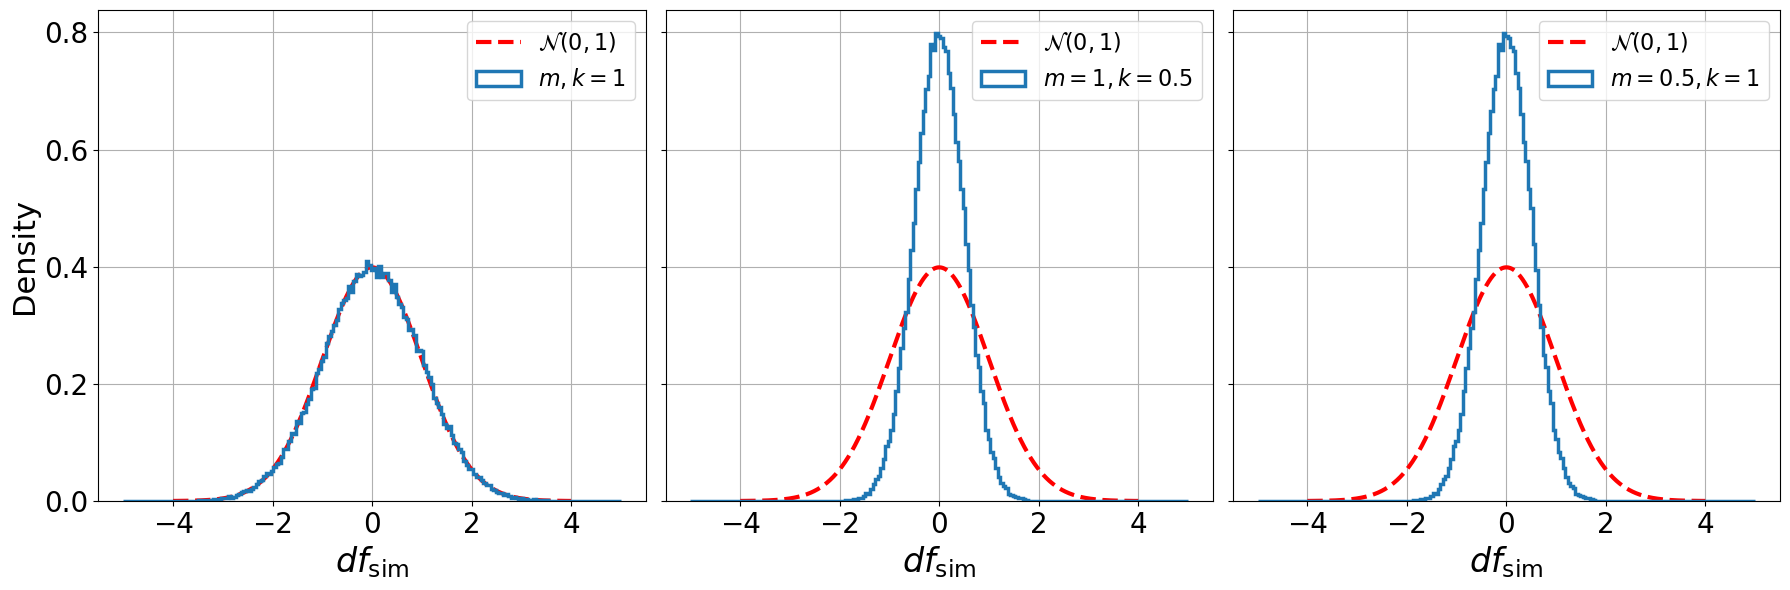

In [15]:
K = {'histtype': 'step', 'bins': np.linspace(-5, 5, 200), 'linewidth': 2.5} 
x = np.linspace(-4, 4, 33266)
y = norm.pdf(x)

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6), sharey=True)

data_list = [df, df_m, df_k]
labels = [r'$m, k = 1$', r'$m = 1, k = 0.5$', r'$m = 0.5, k = 1$']

for i, ax in enumerate(axes):
    ax.plot(x, y, color='red', linestyle='--', linewidth=3.0, label=r'$\mathcal{N}(0,1)$') 
    data_list[i].hist(label=labels[i], ax=ax, density=True, **K)
    
    ax.legend(fontsize=16, loc='upper right')
    ax.tick_params(labelsize=20)
    
    ax.set_xlabel(r"$df_{\mathrm{sim}}$", fontsize=24)
    
    if i == 0:
        ax.set_ylabel("Density", fontsize=22)

plt.tight_layout()
plt.show()